In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential
from keras.layers import Dense,Dropout
from keras_tuner.tuners import RandomSearch
from keras_tuner.engine.hyperparameters import HyperParameters
import os
import warnings
from tensorflow import keras
from tensorflow.keras import layers
from keras_tuner.tuners import RandomSearch
warnings.filterwarnings('ignore')

In [2]:
# Reading the training dataset
train_data = pd.read_csv('train.csv')

# Reading the test dataset
test_data = pd.read_csv('test.csv')

# Total dataset
total_data = train_data.shape[0] + test_data.shape[0]
print(f"Number of dataset in training datasets: {train_data.shape[0]} which is {round(100*train_data.shape[0]/total_data, 2)}% of total datasets.")
print(f"Number of dataset in test datasets: {test_data.shape[0]} which is {round(100*test_data.shape[0]/total_data, 2)}% of total datasets.")

# shape of dataset
print(f"shape of training datasets: {train_data.shape}")
print(f"shape of test datasets: {test_data.shape}")

Number of dataset in training datasets: 7352 which is 71.39% of total datasets.
Number of dataset in test datasets: 2947 which is 28.61% of total datasets.
shape of training datasets: (7352, 563)
shape of test datasets: (2947, 563)


In [3]:
train_data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [4]:
train_data.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515,17.413085
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122,8.975143
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414,8.000000
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181,19.000000
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659,26.000000
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000,30.000000


In [5]:
train_df = train_data
test_df = test_data

In [6]:
# Checking for nan
print("*********CHECKING NAN*********")
print(f"How many Nan values are present in training dataset? \nAns: {train_data.isna().values.sum()}")
print(f"How many Nan values are present in test dataset? \nAns: {test_data.isna().values.sum()}")
print()

# Checking for null
print("*********CHECKING NULL*********")
print(f"How many NULL values are present in training dataset? \nAns: {train_data.isnull().values.sum()}")
print(f"How many NULL values are present in test dataset? \nAns: {test_data.isnull().values.sum()}")
print()

# Checking for duplicates
print("*********CHECKING DUPLICATES*********")
print(f"How many duplicates data re present in training dataset? \nAns: {train_data.duplicated().values.sum()}")
print(f"How many duplicates data re present in test dataset? \nAns: {test_data.duplicated().values.sum()}")

*********CHECKING NAN*********
How many Nan values are present in training dataset? 
Ans: 0
How many Nan values are present in test dataset? 
Ans: 0

*********CHECKING NULL*********
How many NULL values are present in training dataset? 
Ans: 0
How many NULL values are present in test dataset? 
Ans: 0

*********CHECKING DUPLICATES*********
How many duplicates data re present in training dataset? 
Ans: 0
How many duplicates data re present in test dataset? 
Ans: 0


In [7]:
train_features = train_df.drop(["Activity", "subject"], axis=1)
test_features = test_df.drop(["Activity", "subject"], axis=1)

train_labels = train_df["Activity"].replace(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS'],  [0, 1, 2, 3, 4, 5])
test_labels = test_df["Activity"].replace(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS'],  [0, 1, 2, 3, 4, 5])

print(train_features.shape)
print(test_features.shape)

print(train_labels.shape)
print(test_labels.shape)

(7352, 561)
(2947, 561)
(7352,)
(2947,)


In [8]:
X_train = train_features
X_test = test_features

Y_train = train_labels
Y_test = test_labels

In [9]:
columns = train_df.columns
print(columns.shape)
columns

(563,)


Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity'],
      dtype='object', length=563)

In [10]:
mean_X = []
mean_Y = []
mean_Z = []
for i in columns:
    if "mean" in i:
        if "X" in i:
            mean_X.append(i)
        elif "Y" in i:
            mean_Y.append(i)
        elif "Z" in i:
            mean_Z.append(i)
        
print(mean_X)
print(mean_Y)
print(mean_Z)

['tBodyAcc-mean()-X', 'tGravityAcc-mean()-X', 'tBodyAccJerk-mean()-X', 'tBodyGyro-mean()-X', 'tBodyGyroJerk-mean()-X', 'fBodyAcc-mean()-X', 'fBodyAcc-meanFreq()-X', 'fBodyAccJerk-mean()-X', 'fBodyAccJerk-meanFreq()-X', 'fBodyGyro-mean()-X', 'fBodyGyro-meanFreq()-X']
['tBodyAcc-mean()-Y', 'tGravityAcc-mean()-Y', 'tBodyAccJerk-mean()-Y', 'tBodyGyro-mean()-Y', 'tBodyGyroJerk-mean()-Y', 'fBodyAcc-mean()-Y', 'fBodyAcc-meanFreq()-Y', 'fBodyAccJerk-mean()-Y', 'fBodyAccJerk-meanFreq()-Y', 'fBodyGyro-mean()-Y', 'fBodyGyro-meanFreq()-Y']
['tBodyAcc-mean()-Z', 'tGravityAcc-mean()-Z', 'tBodyAccJerk-mean()-Z', 'tBodyGyro-mean()-Z', 'tBodyGyroJerk-mean()-Z', 'fBodyAcc-mean()-Z', 'fBodyAcc-meanFreq()-Z', 'fBodyAccJerk-mean()-Z', 'fBodyAccJerk-meanFreq()-Z', 'fBodyGyro-mean()-Z', 'fBodyGyro-meanFreq()-Z']


In [11]:
min_X = []
min_Y = []
min_Z = []

for i in columns:
    if "min" in i:
        if "X" in i:
            min_X.append(i)
        elif "Y" in i:
            min_Y.append(i)
        elif "Z" in i:
            min_Z.append(i)
        
print(min_X)
print(min_Y)
print(min_Z)

['tBodyAcc-min()-X', 'tGravityAcc-min()-X', 'tBodyAccJerk-min()-X', 'tBodyGyro-min()-X', 'tBodyGyroJerk-min()-X', 'fBodyAcc-min()-X', 'fBodyAccJerk-min()-X', 'fBodyGyro-min()-X']
['tBodyAcc-min()-Y', 'tGravityAcc-min()-Y', 'tBodyAccJerk-min()-Y', 'tBodyGyro-min()-Y', 'tBodyGyroJerk-min()-Y', 'fBodyAcc-min()-Y', 'fBodyAccJerk-min()-Y', 'fBodyGyro-min()-Y']
['tBodyAcc-min()-Z', 'tGravityAcc-min()-Z', 'tBodyAccJerk-min()-Z', 'tBodyGyro-min()-Z', 'tBodyGyroJerk-min()-Z', 'fBodyAcc-min()-Z', 'fBodyAccJerk-min()-Z', 'fBodyGyro-min()-Z']


## EDA

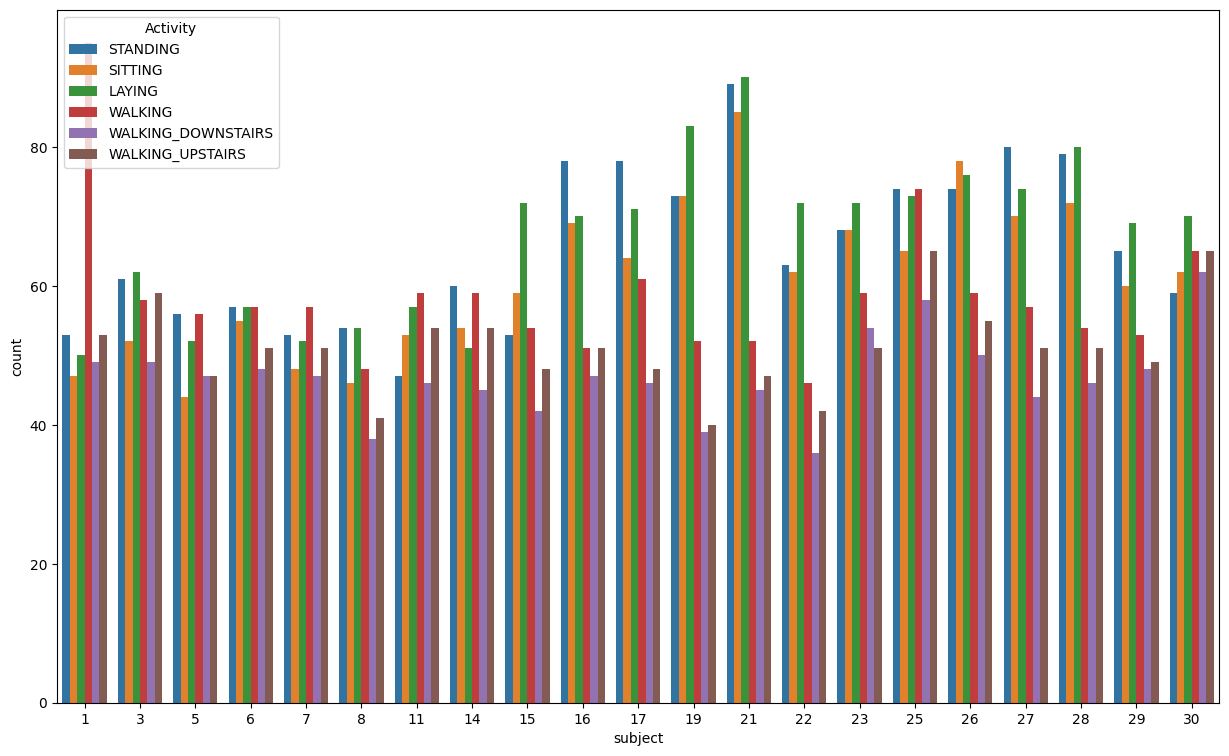

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,9))
sns.countplot(x='subject', hue='Activity', data=train_data)

plt.show()

<Axes: xlabel='Activity', ylabel='count'>

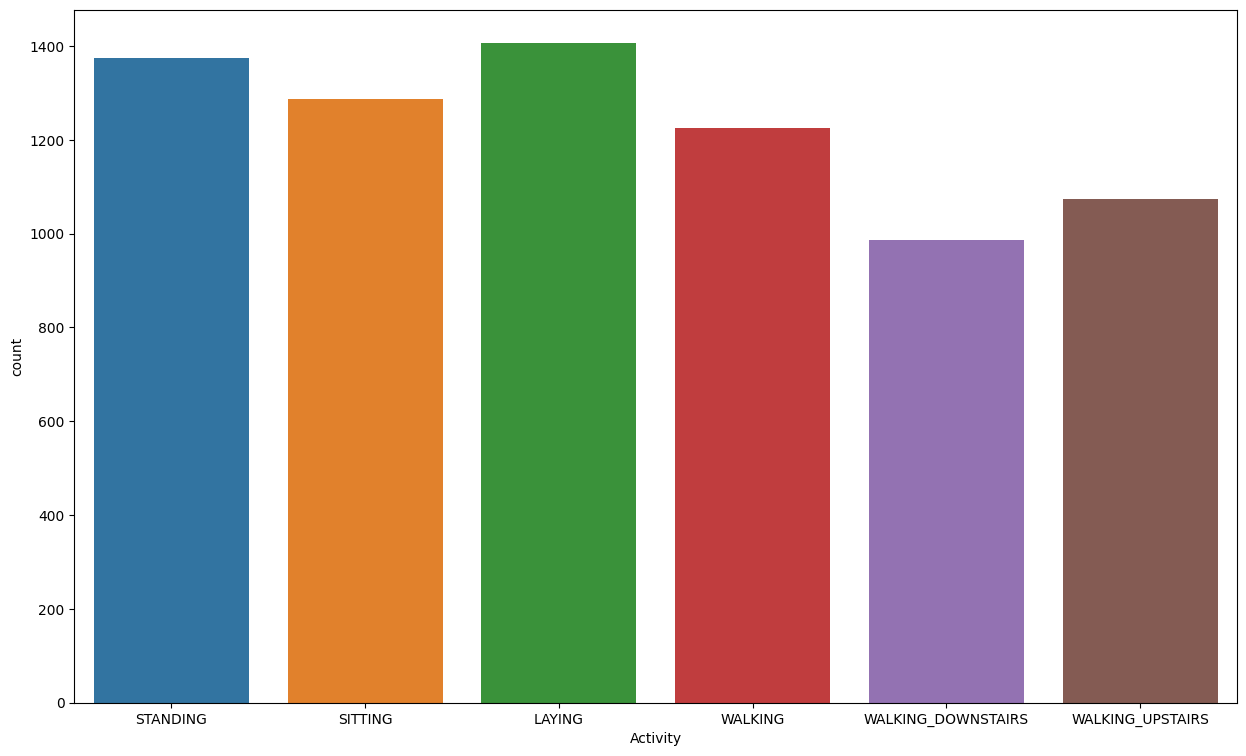

In [13]:
plt.figure(figsize=(15,9))
sns.countplot(x= "Activity", hue="Activity", data=train_data, dodge=False)
# plt.xticks(rotation=45)

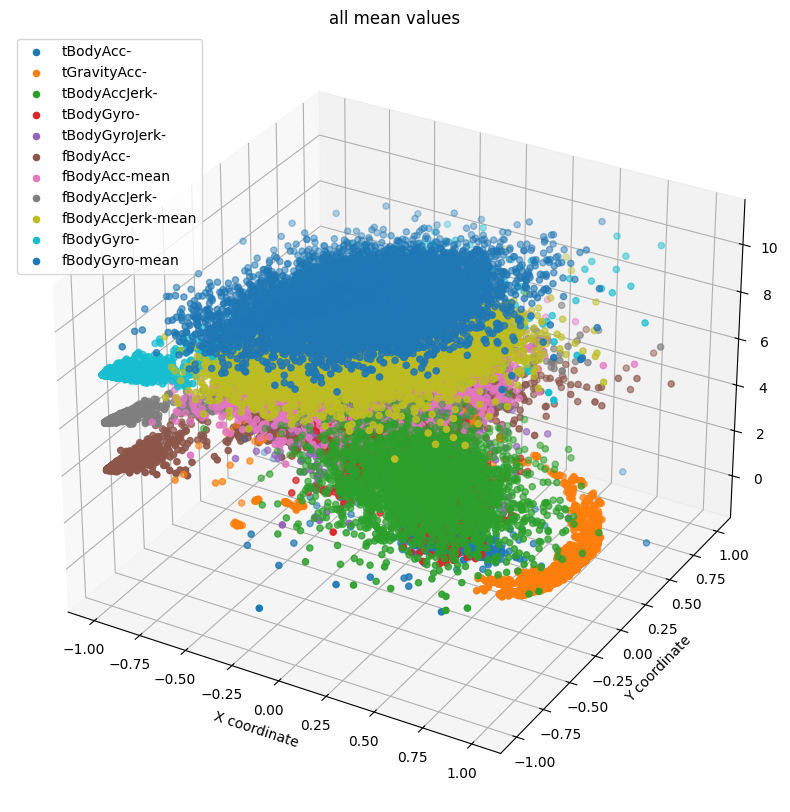

In [14]:
fig = plt.figure(figsize=(10, 10))
axs = plt.axes(projection="3d")

for i in range(len(mean_X)):
    axs.scatter(train_data[mean_X[i]].values, train_data[mean_Y[i]].values, train_data[mean_Z[i]].values+i, label=mean_X[i][0:-8])

plt.title("all mean values")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.legend(loc="upper left")
plt.show()


In [15]:
np.unique(train_df["Activity"])

array(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], dtype=object)

[Text(0, 0, 'LAYING'),
 Text(1, 0, 'SITTING'),
 Text(2, 0, 'STANDING'),
 Text(3, 0, 'WALKING'),
 Text(4, 0, 'WALKING_DOWNSTAIRS'),
 Text(5, 0, 'WALKING_UPSTAIRS')]

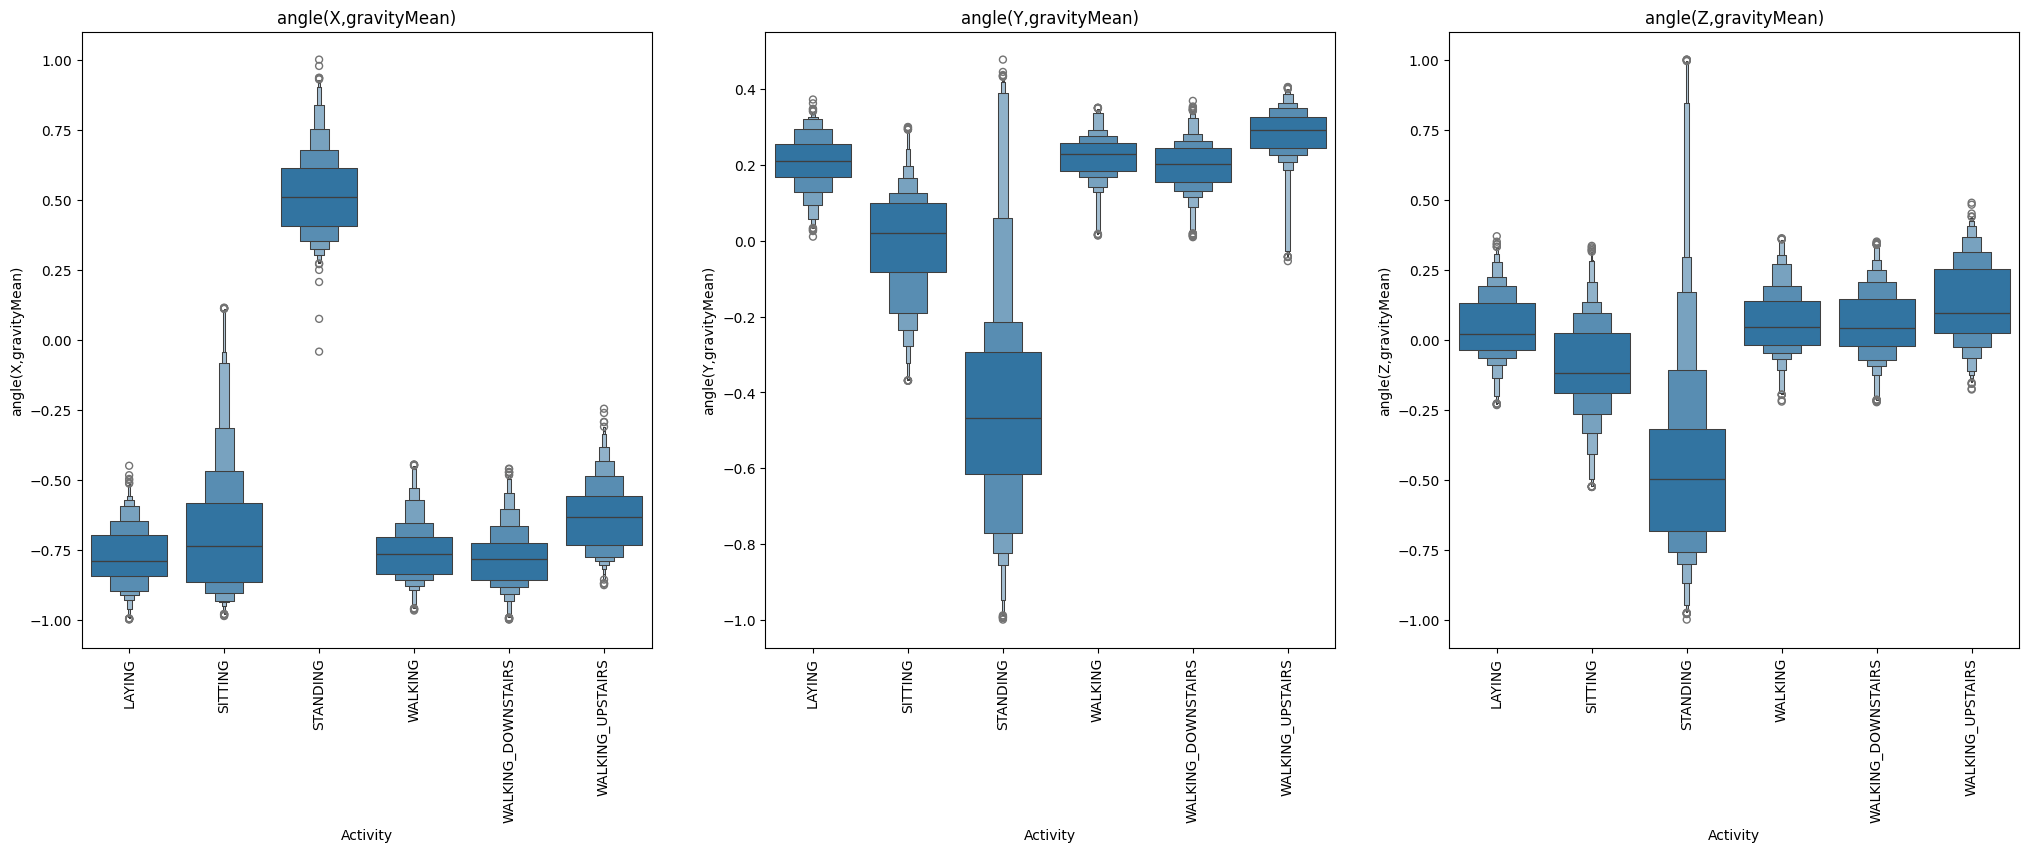

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(25, 8))
sns.boxenplot(ax = axs[0], x="Activity", y="angle(X,gravityMean)", data=train_df)
sns.boxenplot(ax = axs[1], x="Activity", y="angle(Y,gravityMean)", data=train_df)
sns.boxenplot(ax = axs[2], x="Activity", y="angle(Z,gravityMean)", data=train_df)

axs[0].set_title("angle(X,gravityMean)")
axs[0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], rotation="vertical")

axs[1].set_title("angle(Y,gravityMean)")
axs[1].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], rotation="vertical")

axs[2].set_title("angle(Z,gravityMean)")
axs[2].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
       'WALKING_UPSTAIRS'], rotation="vertical")

In [17]:
min_X = []
min_Y = []
min_Z = []

mean_X = []
mean_Y = []
mean_Z = []

max_X = []
max_Y = []
max_Z = []

for i in columns:
    if "min" in i:
        if "X" in i:
            min_X.append(i)
            mean_X.append(i.replace("min", "mean"))
            max_X.append(i.replace("min", "max"))
        elif "Y" in i:
            min_Y.append(i)
            mean_Y.append(i.replace("min", "mean"))
            max_Y.append(i.replace("min", "mean"))
        elif "Z" in i:
            min_Z.append(i)
            mean_Z.append(i.replace("min", "mean"))
            max_Z.append(i.replace("min", "mean"))

        
print(min_X)
print(min_Y)
print(min_Z, "\n")

print(mean_X)
print(mean_Y)
print(mean_Z, "\n")

print(max_X)
print(max_Y)
print(max_Z, "\n")

['tBodyAcc-min()-X', 'tGravityAcc-min()-X', 'tBodyAccJerk-min()-X', 'tBodyGyro-min()-X', 'tBodyGyroJerk-min()-X', 'fBodyAcc-min()-X', 'fBodyAccJerk-min()-X', 'fBodyGyro-min()-X']
['tBodyAcc-min()-Y', 'tGravityAcc-min()-Y', 'tBodyAccJerk-min()-Y', 'tBodyGyro-min()-Y', 'tBodyGyroJerk-min()-Y', 'fBodyAcc-min()-Y', 'fBodyAccJerk-min()-Y', 'fBodyGyro-min()-Y']
['tBodyAcc-min()-Z', 'tGravityAcc-min()-Z', 'tBodyAccJerk-min()-Z', 'tBodyGyro-min()-Z', 'tBodyGyroJerk-min()-Z', 'fBodyAcc-min()-Z', 'fBodyAccJerk-min()-Z', 'fBodyGyro-min()-Z'] 

['tBodyAcc-mean()-X', 'tGravityAcc-mean()-X', 'tBodyAccJerk-mean()-X', 'tBodyGyro-mean()-X', 'tBodyGyroJerk-mean()-X', 'fBodyAcc-mean()-X', 'fBodyAccJerk-mean()-X', 'fBodyGyro-mean()-X']
['tBodyAcc-mean()-Y', 'tGravityAcc-mean()-Y', 'tBodyAccJerk-mean()-Y', 'tBodyGyro-mean()-Y', 'tBodyGyroJerk-mean()-Y', 'fBodyAcc-mean()-Y', 'fBodyAccJerk-mean()-Y', 'fBodyGyro-mean()-Y']
['tBodyAcc-mean()-Z', 'tGravityAcc-mean()-Z', 'tBodyAccJerk-mean()-Z', 'tBodyGyro-mean(

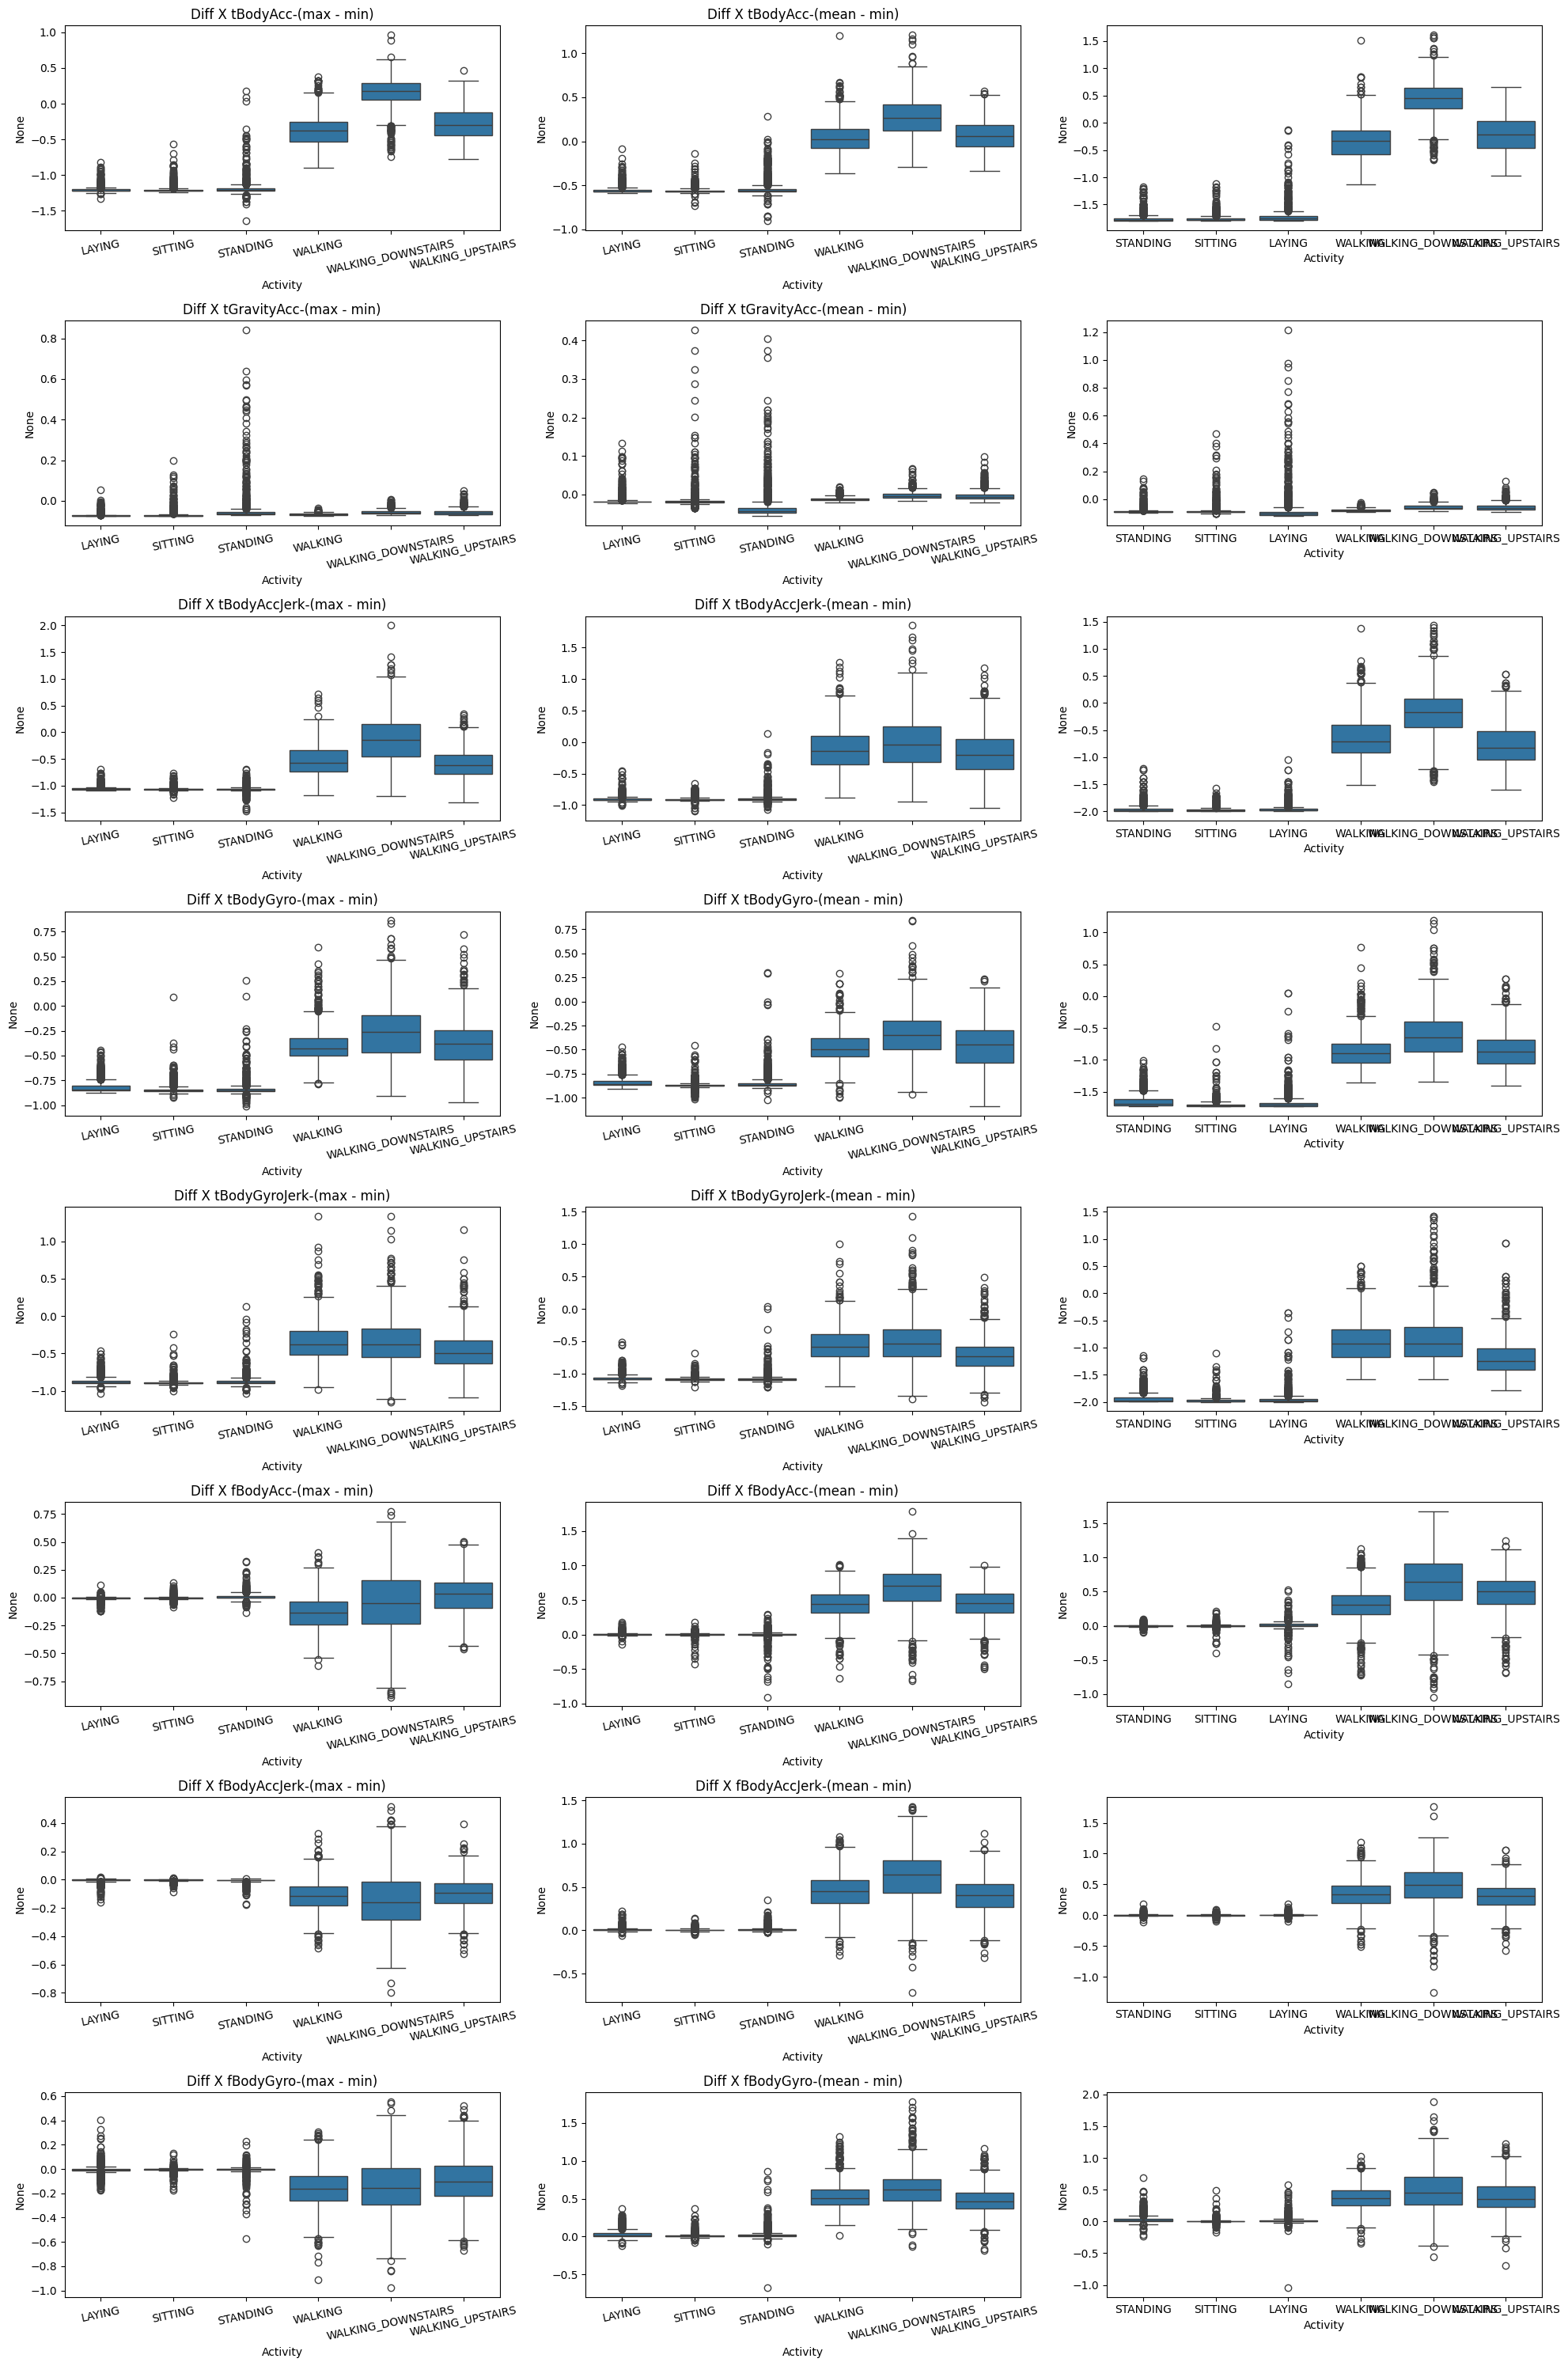

In [18]:
fig, axs = plt.subplots(len(min_X), 3, figsize=(20, 30))

for i in range(len(min_X)):
    mean_min_X = train_df[mean_X[i]] - train_df[min_X[i]]
    max_mean_X = train_df[max_X[i]] - train_df[mean_X[i]]
    max_min_X = train_df[max_X[i]] - train_df[min_X[i]]
    
#     mean_min_Y = train_df[mean_Y[i]] - train_df[min_Y[i]]
#     max_mean_Y = train_df[max_Y[i]] - train_df[mean_Y[i]]
#     max_min_Y = train_df[max_Y[i]] - train_df[min_Y[i]]
    
#     mean_min_Z = train_df[mean_Z[i]] - train_df[min_Z[i]]
#     max_mean_Z = train_df[max_Z[i]] - train_df[mean_Z[i]]
#     max_min_Z = train_df[max_Z[i]] - train_df[min_Z[i]]
    
    sns.boxplot(ax=axs[i, 0], x=train_df["Activity"], y=max_mean_X)
    sns.boxplot(ax=axs[i, 1], x=train_df["Activity"], y=mean_min_X)
    sns.boxplot(ax=axs[i, 2], x=train_df["Activity"], y=max_min_X)
    
    axs[i, 0].set_title("Diff X "+mean_X[i][0:-8]+"(max - mean)")
    axs[i, 0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)

    axs[i, 1].set_title("Diff X "+mean_X[i][0:-8]+"(mean - min)")
    axs[i, 1].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)
    
    axs[i, 0].set_title("Diff X "+mean_X[i][0:-8]+"(max - min)")
    axs[i, 0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)
    
plt.tight_layout()

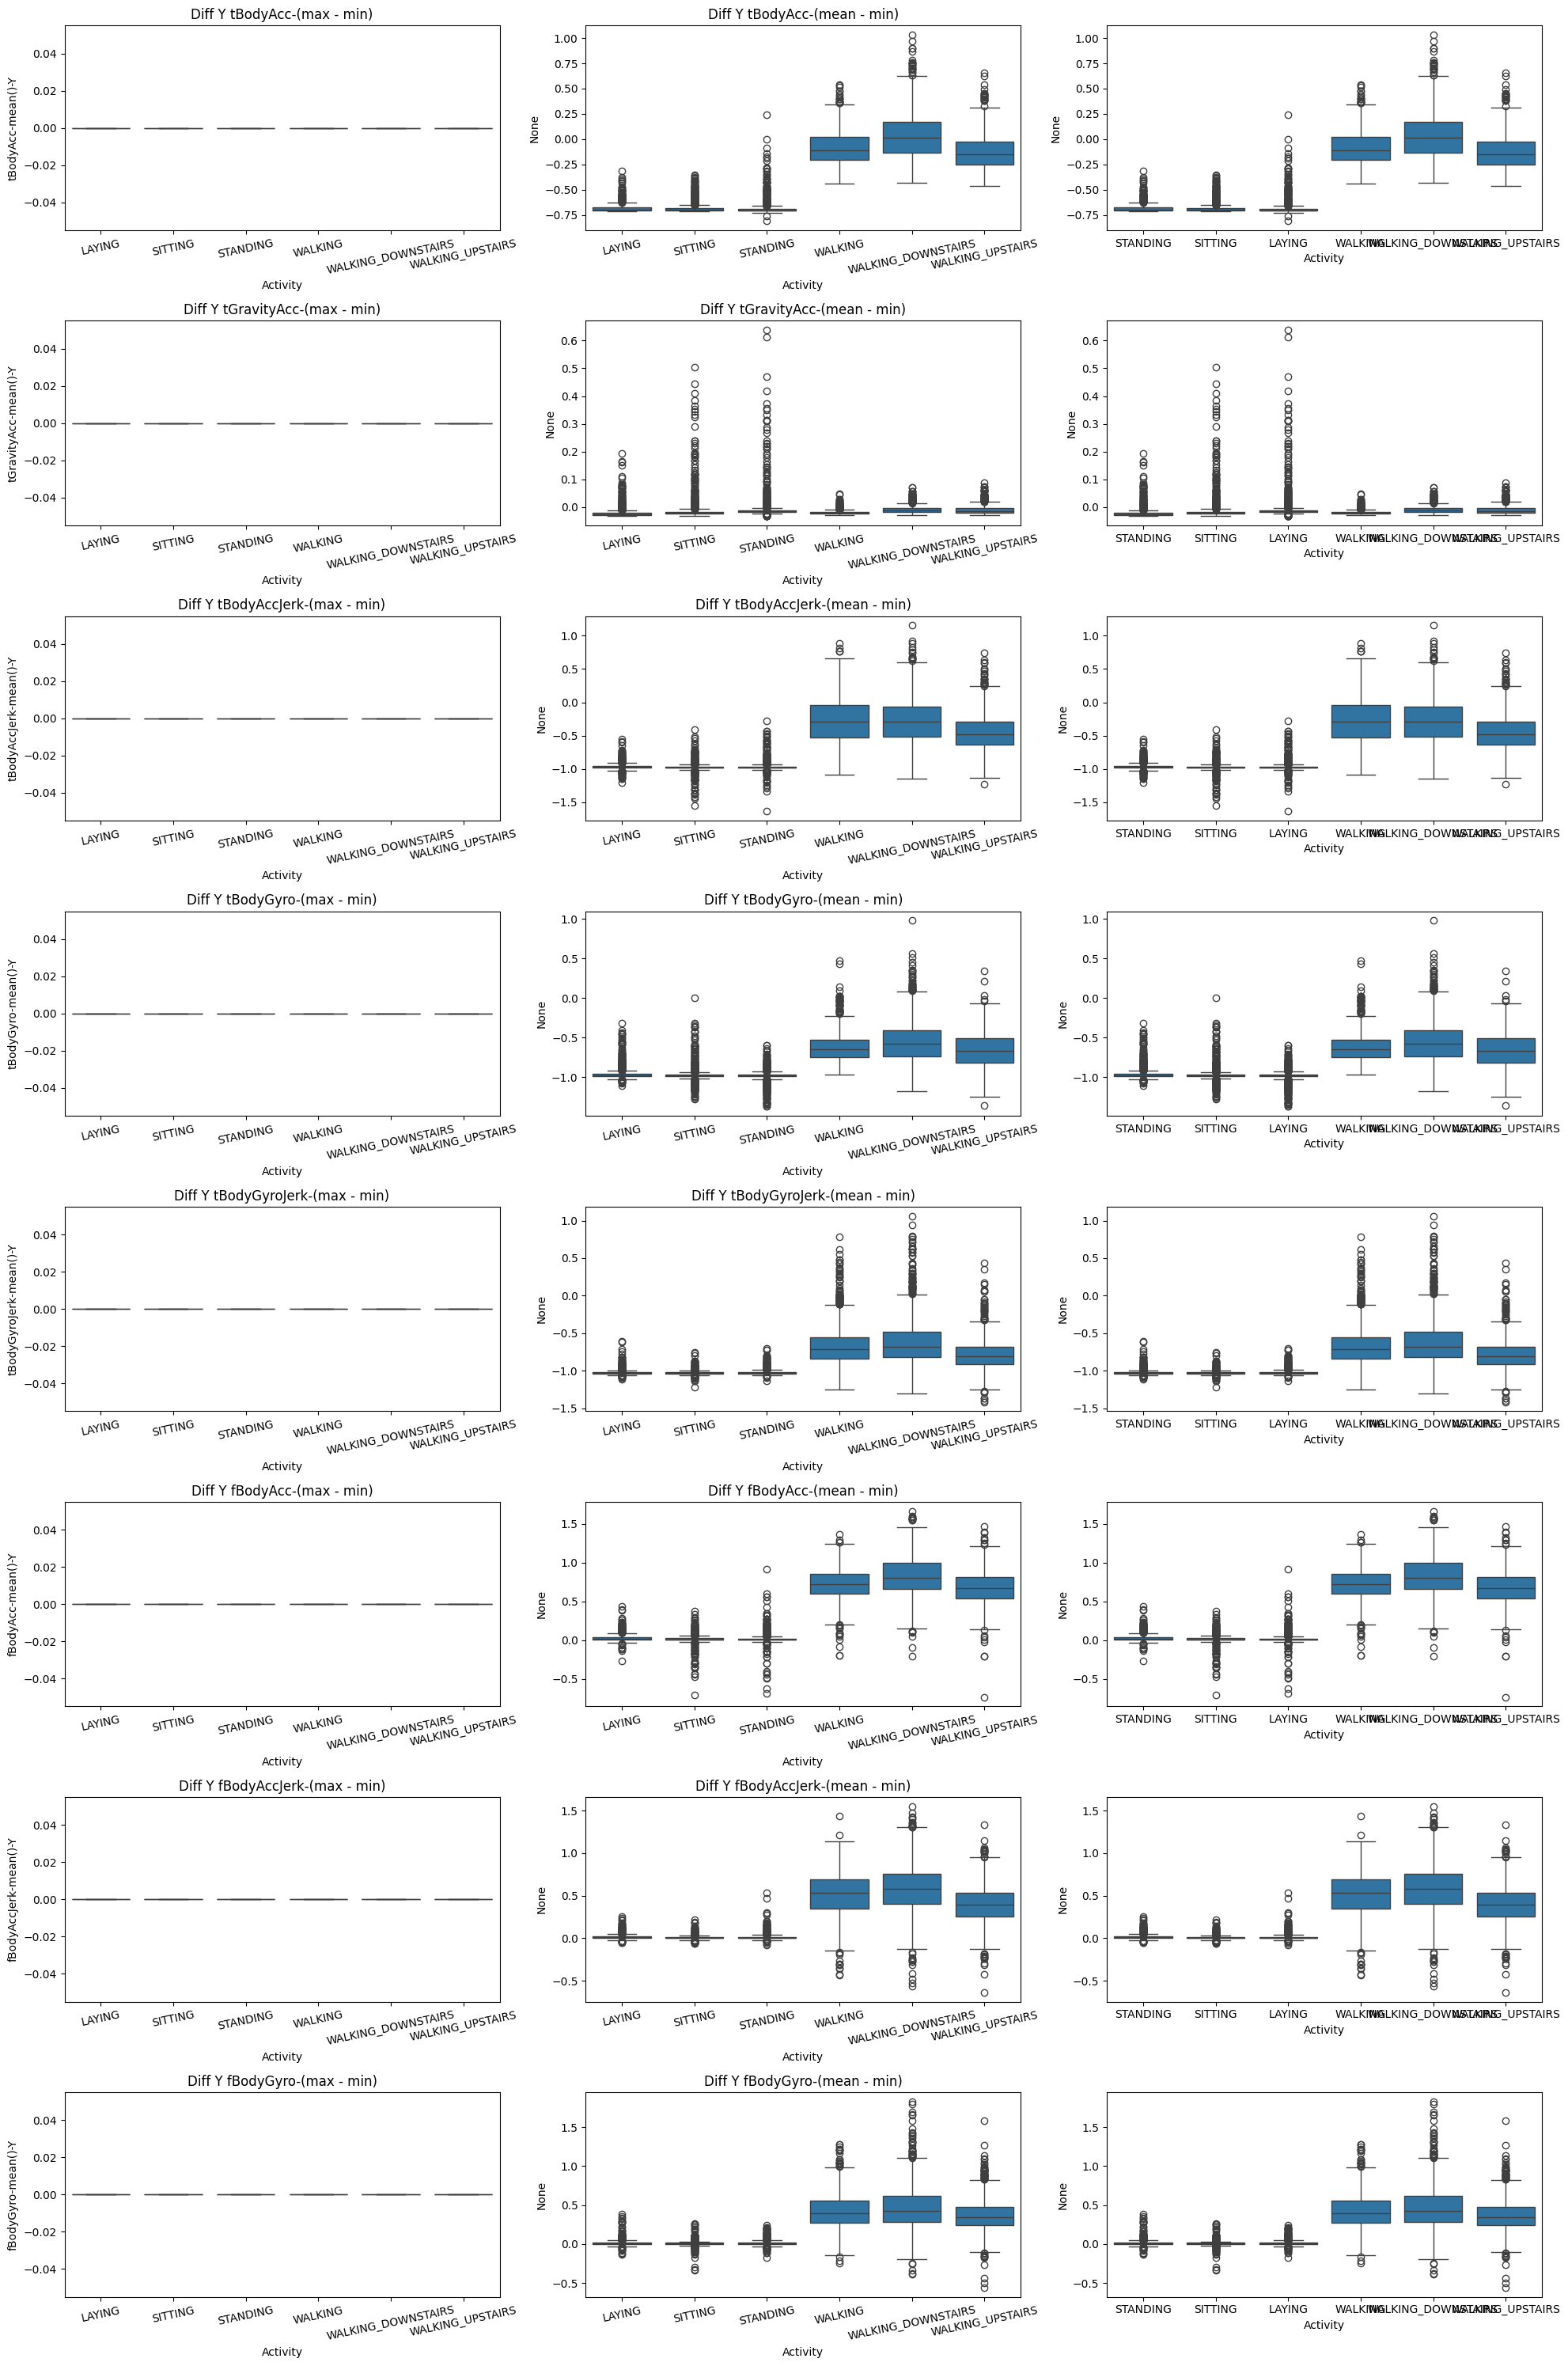

In [19]:
fig, axs = plt.subplots(len(min_X), 3, figsize=(20, 30))

for i in range(len(min_X)):
    
    mean_min_Y = train_df[mean_Y[i]] - train_df[min_Y[i]]
    max_mean_Y = train_df[max_Y[i]] - train_df[mean_Y[i]]
    max_min_Y = train_df[max_Y[i]] - train_df[min_Y[i]]
    
    sns.boxplot(ax=axs[i, 0], x=train_df["Activity"], y=max_mean_Y)
    sns.boxplot(ax=axs[i, 1], x=train_df["Activity"], y=mean_min_Y)
    sns.boxplot(ax=axs[i, 2], x=train_df["Activity"], y=max_min_Y)
    
    axs[i, 0].set_title("Diff Y "+mean_X[i][0:-8]+"(max - mean)")
    axs[i, 0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)

    axs[i, 1].set_title("Diff Y "+mean_X[i][0:-8]+"(mean - min)")
    axs[i, 1].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)
    
    axs[i, 0].set_title("Diff Y "+mean_X[i][0:-8]+"(max - min)")
    axs[i, 0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)
    
plt.tight_layout() 

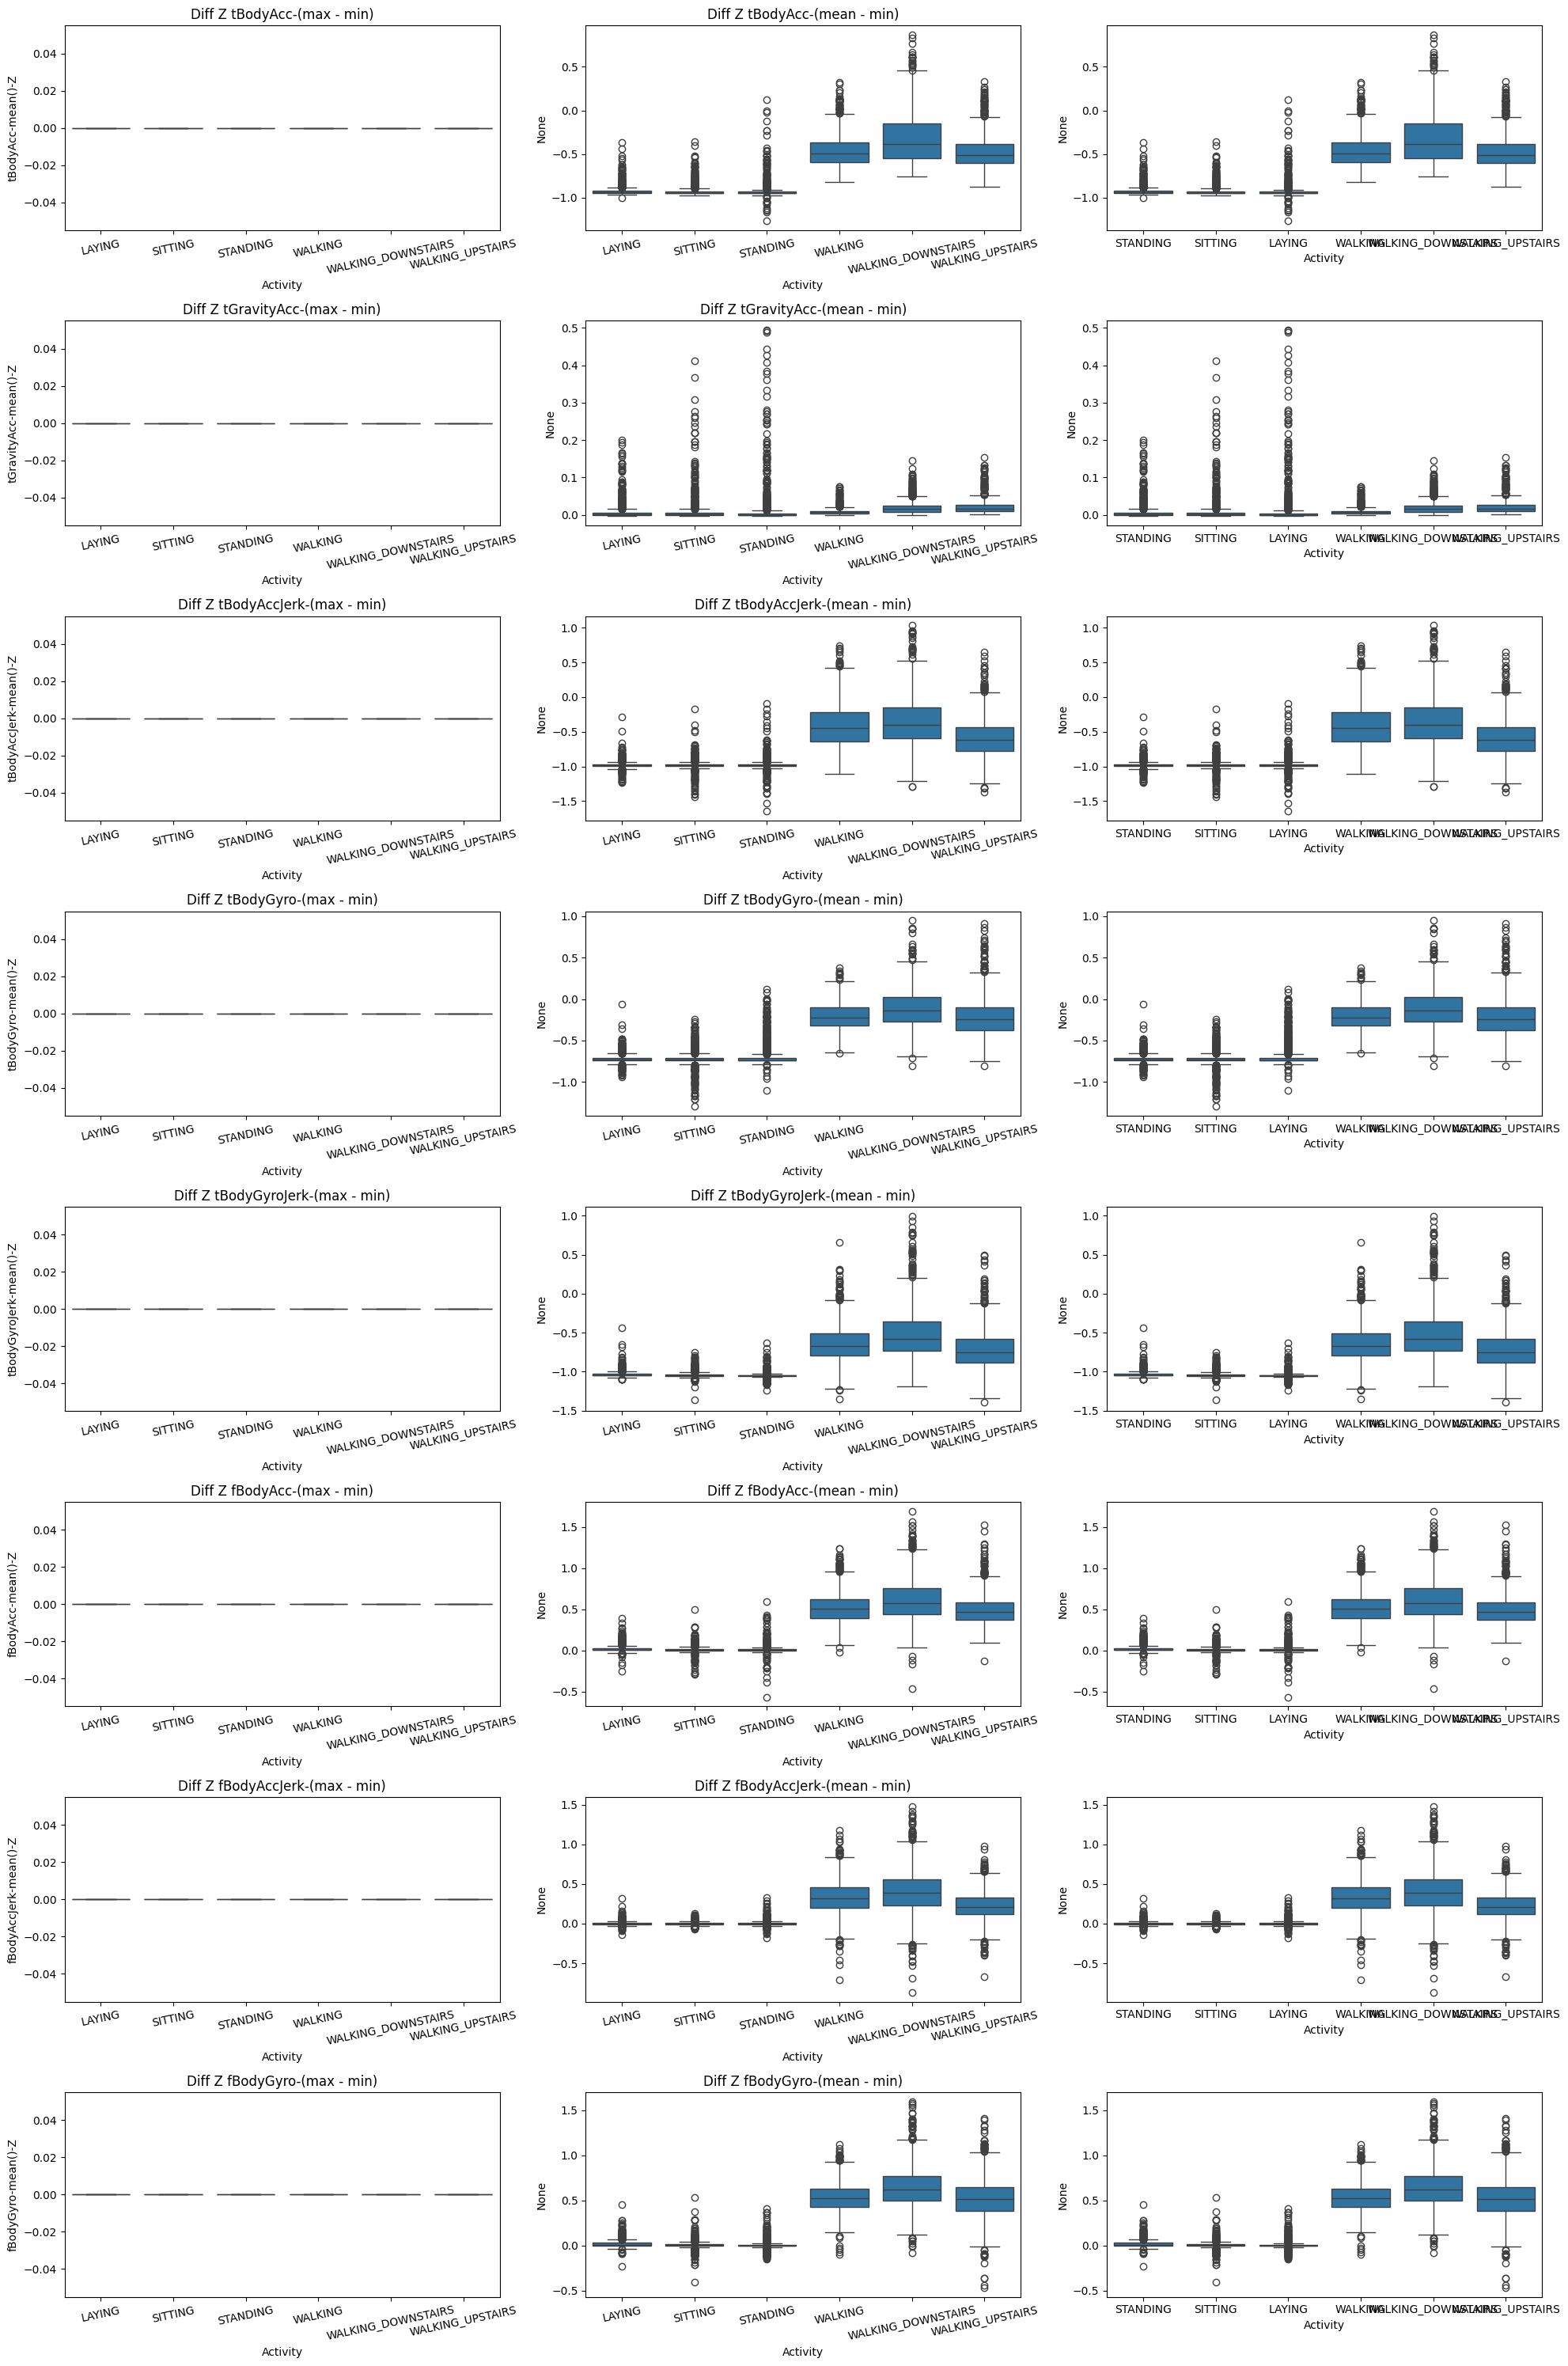

In [20]:
fig, axs = plt.subplots(len(min_X), 3, figsize=(20, 30))

for i in range(len(min_X)):
    
    mean_min_Z = train_df[mean_Z[i]] - train_df[min_Z[i]]
    max_mean_Z = train_df[max_Z[i]] - train_df[mean_Z[i]]
    max_min_Z = train_df[max_Z[i]] - train_df[min_Z[i]]
    
    sns.boxplot(ax=axs[i, 0], x=train_df["Activity"], y=max_mean_Z)
    sns.boxplot(ax=axs[i, 1], x=train_df["Activity"], y=mean_min_Z)
    sns.boxplot(ax=axs[i, 2], x=train_df["Activity"], y=max_min_Z)
    
    axs[i, 0].set_title("Diff Z "+mean_X[i][0:-8]+"(max - mean)")
    axs[i, 0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)

    axs[i, 1].set_title("Diff Z "+mean_X[i][0:-8]+"(mean - min)")
    axs[i, 1].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)
    
    axs[i, 0].set_title("Diff Z "+mean_X[i][0:-8]+"(max - min)")
    axs[i, 0].set_xticklabels(['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS',
           'WALKING_UPSTAIRS'], rotation=12)
    
plt.tight_layout()

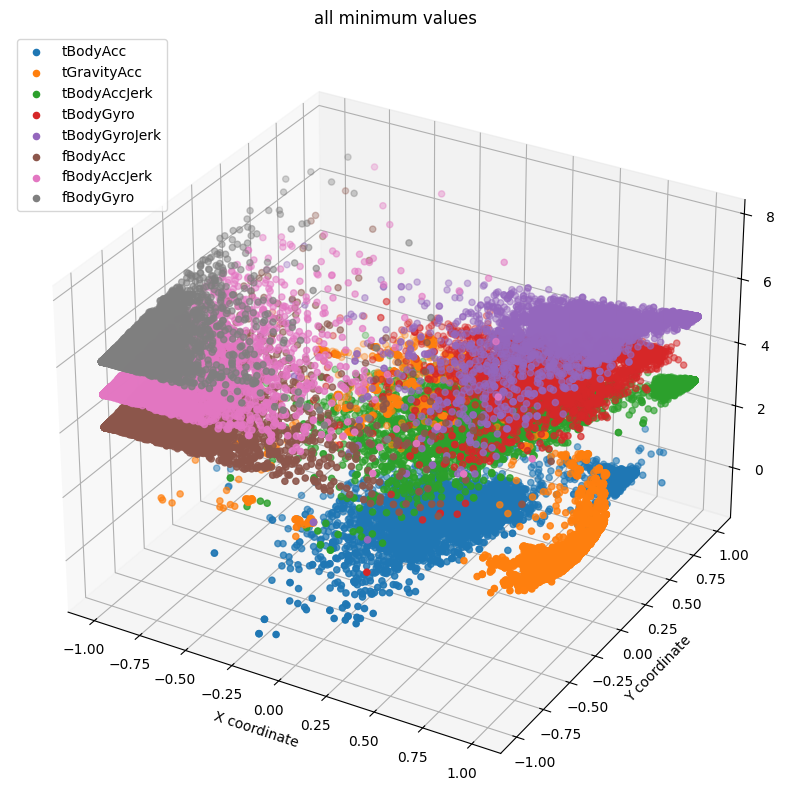

In [21]:
fig = plt.figure(figsize=(10, 10))
axs = plt.axes(projection="3d")

for i in range(len(min_X)):
    axs.scatter(train_df[min_X[i]].values, train_df[min_Y[i]].values, train_df[min_Y[i]].values+i, label=min_X[i][0:-8])

plt.title("all minimum values")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.legend(loc="upper left")
plt.show()

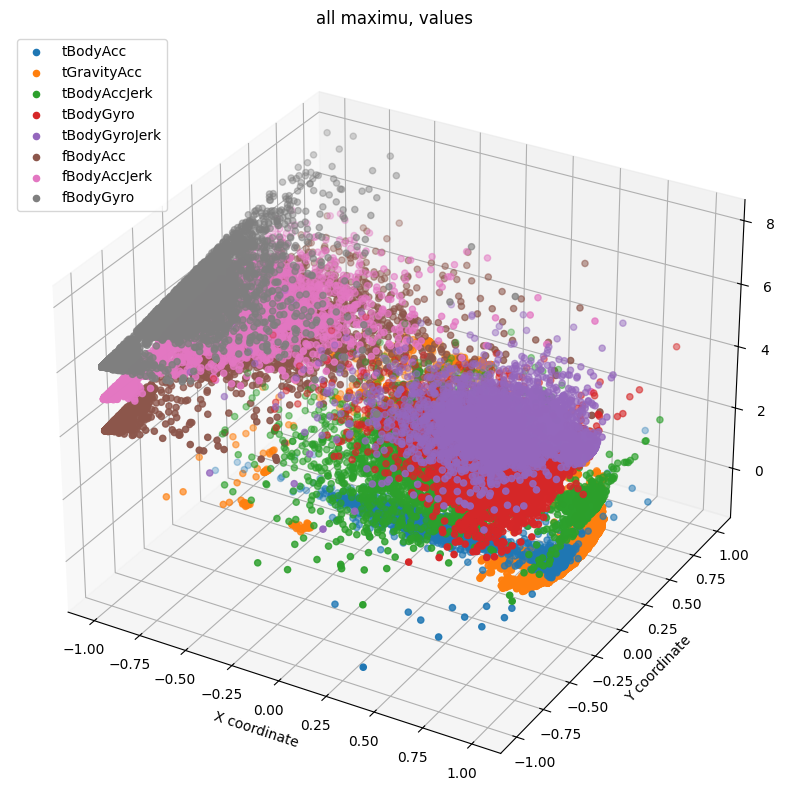

In [22]:
fig = plt.figure(figsize=(10, 10))
axs = plt.axes(projection="3d")

for i in range(len(max_X)):
    axs.scatter(train_df[min_X[i]].values, train_df[max_Y[i]].values, train_df[max_Y[i]].values+i, label=max_X[i][0:-8])

plt.title("all maximu, values")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.legend(loc="upper left")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


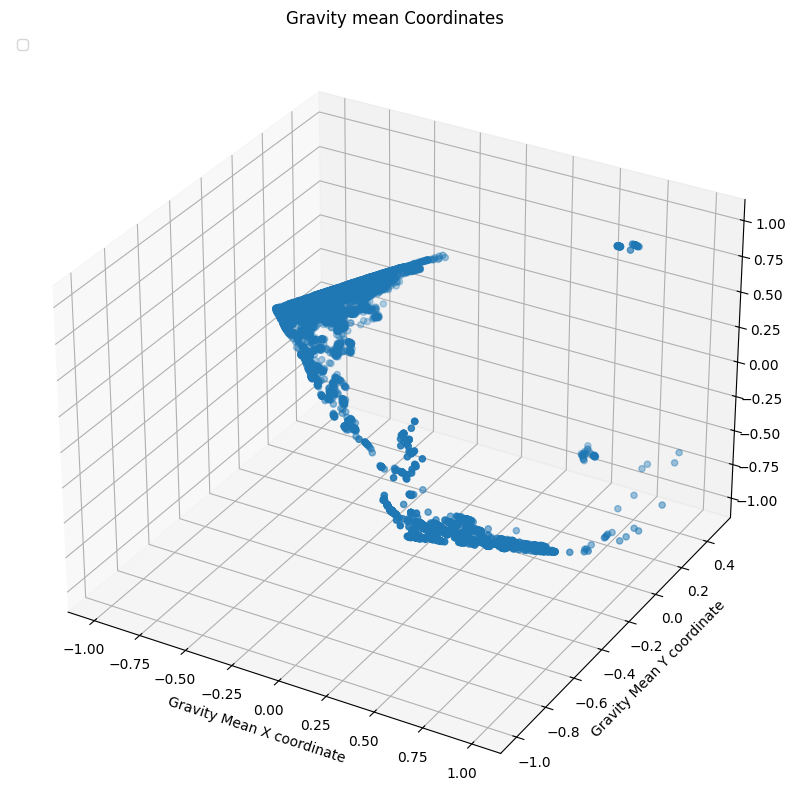

In [23]:
fig = plt.figure(figsize=(10, 10))
axs = plt.axes(projection="3d")

angle_X_gravityMean = train_df["angle(X,gravityMean)"].values
angle_Y_gravityMean = train_df["angle(Y,gravityMean)"].values
angle_Z_gravityMean = train_df["angle(Z,gravityMean)"].values

axs.scatter(angle_X_gravityMean, angle_Y_gravityMean, angle_Z_gravityMean)

plt.title("Gravity mean Coordinates")
plt.xlabel("Gravity Mean X coordinate")
plt.ylabel("Gravity Mean Y coordinate")
# plt.set_zlabel("Gravity Mean Z coordinate")
plt.legend(loc="upper left")
plt.show()

In [24]:
def Graph_Drawing(history, title):
    x = np.arange(len(history.history["val_accuracy"]))

    plt.plot(x, history.history["loss"], label="loss")
    plt.plot(x, history.history["val_loss"], label="val_loss")

    plt.plot(x, history.history["accuracy"], label="accuracy")
    plt.plot(x, history.history["val_accuracy"], label="val_accuracy")
    
    plt.title(title)

    plt.legend()

# Applying Machine Learning models

In [25]:
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [26]:
knn = KNeighborsClassifier(n_neighbors=3)
rfc = RandomForestClassifier()
svc = SVC()

In [27]:
knn.fit( train_features, train_labels )

rfc.fit( train_features, train_labels )

svc.fit( train_features, train_labels )

SVC()

In [28]:
print("Shape of test_features:", test_features.shape)
print("Data type of test_features:", type(test_features))

Shape of test_features: (2947, 561)
Data type of test_features: <class 'pandas.core.frame.DataFrame'>


In [29]:
test_features_array = test_features.values

# Evaluate the performance of each classifier
knn_score = knn.score(test_features_array, test_labels)
rfc_score = rfc.score(test_features_array, test_labels)
svc_score = svc.score(test_features_array, test_labels)

print("KNN Score:", knn_score)
print("Random Forest Score:", rfc_score)
print("SVC Score:", svc_score)

KNN Score: 0.8907363420427553
Random Forest Score: 0.9243298269426535
SVC Score: 0.9504580929759077


# Applying Deep Learning models

In [30]:
import tensorflow as tf
import keras
from keras import layers
from keras.callbacks import EarlyStopping

In [31]:
def ANN_Model(data):
    model = keras.Sequential([
        layers.Input(shape=data.shape[1:]),

        layers.Dense(100, activation="relu"),
    #         layers.Dropout(0.1),
    #         layers.BatchNormalization(),

        layers.Dense(64, activation="relu"),
    #         layers.Dropout(0.25),
    #         layers.BatchNormalization(),

        layers.Dense(6, activation="softmax"),

    ], name="MLP_Sequential")

    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    #     print(model.summary())
    return model

# Convolutional Neural Network Model

def CNN_Model(data):
    model = keras.Sequential(name="CNN_Sequential")
    print(data.shape[1:])
    model.add(layers.Input(shape=data.shape[1:]))
    model.add(layers.Conv1D(64, 3, activation="relu", name="conv_1"))
#         layers.Dropout(0.1),
    model.add(layers.Conv1D(32, 3, activation="relu", name="conv_2"))
#         layers.Dropout(0.1),
    
    model.add(layers.Flatten())

    model.add(layers.Dense(64, activation="relu", name="dense_1"))
    model.add(layers.Dense(128, activation="relu", name="dense_2"))
    model.add(layers.Dense(6, activation="softmax", name="output"))
    
    model.compile(optimizer=tf.keras.optimizers.SGD(), 
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    
    print(model.summary())
    
    return model


## Training Models

### Artifical Neural Network

In [32]:
ann_model = ANN_Model(train_features)
ann_model.summary()

earlystopping = EarlyStopping(patience=30, monitor="val_accuracy", restore_best_weights=True)
ann_history = ann_model.fit(train_features, train_labels, epochs=100, callbacks = [earlystopping],
         validation_data=(test_features, test_labels) )



Model: "MLP_Sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 100)               56200     
                                                                 
 dense_1 (Dense)             (None, 64)                6464      
                                                                 
 dense_2 (Dense)             (None, 6)                 390       
                                                                 
Total params: 63054 (246.30 KB)
Trainable params: 63054 (246.30 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 1/100


230/230 [==============================] - 3s 6ms/step - loss: 0.4194 - accuracy: 0.8498 - val_loss: 0.2393 - val_accuracy: 0.8999
Epoch 2/100
230/230 [==============================] - 1s 4ms/step - loss: 0.1556 - accuracy: 0.9378 - val_loss: 0.1709 - val_accur

Epoch 46/100
230/230 [==============================] - 1s 5ms/step - loss: 0.0402 - accuracy: 0.9846 - val_loss: 0.2010 - val_accuracy: 0.9477
Epoch 47/100
230/230 [==============================] - 1s 5ms/step - loss: 0.0240 - accuracy: 0.9909 - val_loss: 0.2412 - val_accuracy: 0.9460
Epoch 48/100
230/230 [==============================] - 1s 4ms/step - loss: 0.0237 - accuracy: 0.9903 - val_loss: 0.2052 - val_accuracy: 0.9518
Epoch 49/100
230/230 [==============================] - 1s 4ms/step - loss: 0.0286 - accuracy: 0.9903 - val_loss: 0.1851 - val_accuracy: 0.9559
Epoch 50/100
230/230 [==============================] - 1s 4ms/step - loss: 0.0273 - accuracy: 0.9888 - val_loss: 0.2817 - val_accuracy: 0.9427
Epoch 51/100
230/230 [==============================] - 1s 4ms/step - loss: 0.0192 - accuracy: 0.9927 - val_loss: 0.2199 - val_accuracy: 0.9511
Epoch 52/100
230/230 [==============================] - 1s 5ms/step - loss: 0.0394 - accuracy: 0.9874 - val_loss: 0.3286 - val_accuracy:

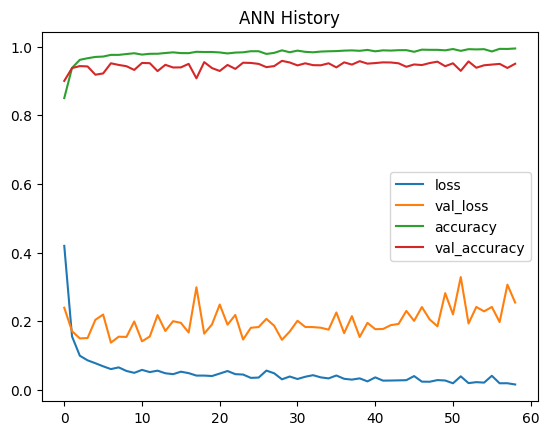

In [33]:
Graph_Drawing(ann_history, "ANN History")

93/93 [==============================] - 0s 2ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

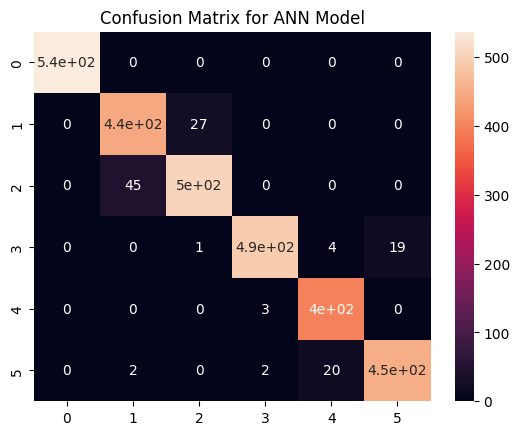

In [34]:
import numpy as np
from sklearn import metrics
import seaborn as sns

ann_predict = ann_model.predict(test_features)
original = test_labels

ann_predict = np.argmax(ann_predict, axis=1)
cf = metrics.confusion_matrix(ann_predict, original)

sns.heatmap(cf, annot=True)
plt.title('Confusion Matrix for ANN Model')
plt.show

In [35]:
ann_model.evaluate(test_features, test_labels.replace(np.unique(test_labels),  [0, 1, 2, 3, 4, 5]))

93/93 [==============================] - 0s 3ms/step - loss: 0.1459 - accuracy: 0.9583


[0.14585663378238678, 0.9582626223564148]

## Covolutional Neural Network

In [36]:
train_features = train_features.values.reshape(train_features.shape[0], train_features.shape[1], 1)
test_features = test_features.values.reshape(test_features.shape[0], test_features.shape[1], 1)

In [37]:
cnn_model = CNN_Model(train_features)
cnn_model.summary()

earlystopping = EarlyStopping(patience=30, monitor="val_accuracy", restore_best_weights=True)
cnn_history = cnn_model.fit( train_features,
                            train_labels, epochs=100, callbacks = [earlystopping],
                            validation_data=(test_features, test_labels) )

(561, 1)
Model: "CNN_Sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv_1 (Conv1D)             (None, 559, 64)           256       
                                                                 
 conv_2 (Conv1D)             (None, 557, 32)           6176      
                                                                 
 flatten (Flatten)           (None, 17824)             0         
                                                                 
 dense_1 (Dense)             (None, 64)                1140800   
                                                                 
 dense_2 (Dense)             (None, 128)               8320      
                                                                 
 output (Dense)              (None, 6)                 774       
                                                                 
Total params: 1156326 (4.41 MB)
Trainable p

230/230 [==============================] - 5s 22ms/step - loss: 0.0017 - accuracy: 1.0000 - val_loss: 0.1448 - val_accuracy: 0.9674
Epoch 97/100
230/230 [==============================] - 6s 24ms/step - loss: 0.0017 - accuracy: 1.0000 - val_loss: 0.1670 - val_accuracy: 0.9630
Epoch 98/100
230/230 [==============================] - 5s 20ms/step - loss: 0.0018 - accuracy: 0.9999 - val_loss: 0.1507 - val_accuracy: 0.9664
Epoch 99/100
230/230 [==============================] - 4s 18ms/step - loss: 0.0015 - accuracy: 1.0000 - val_loss: 0.1597 - val_accuracy: 0.9664
Epoch 100/100
230/230 [==============================] - 4s 19ms/step - loss: 0.0015 - accuracy: 1.0000 - val_loss: 0.1747 - val_accuracy: 0.9603


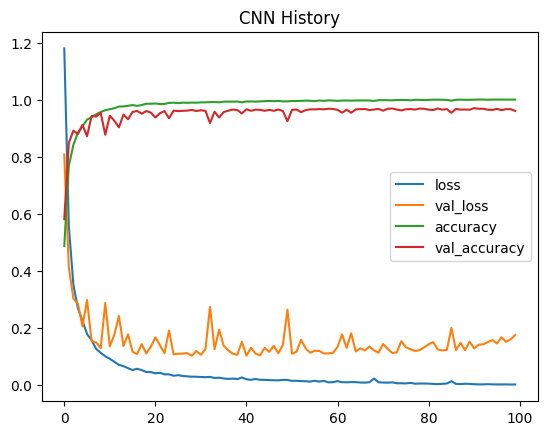

In [38]:
Graph_Drawing(cnn_history, "CNN History")

In [39]:
test_features.shape

(2947, 561, 1)

93/93 [==============================] - 1s 5ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

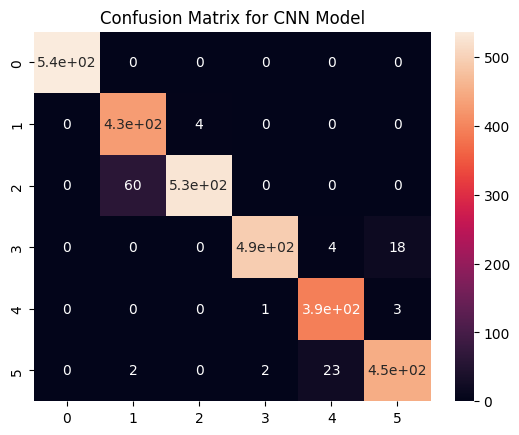

In [40]:
cnn_predict = cnn_model.predict( test_features )
original = test_labels

cnn_predict = np.argmax(cnn_predict, axis=1)
cf = metrics.confusion_matrix(cnn_predict, original)

sns.heatmap(cf, annot=True)
plt.title('Confusion Matrix for CNN Model')
plt.show

In [41]:
cnn_model.evaluate(test_features, test_labels)

93/93 [==============================] - 0s 5ms/step - loss: 0.1747 - accuracy: 0.9603


[0.17473359405994415, 0.9602985978126526]

In [42]:
def CNN_LSTM_Model_Advanced(data):
    model = keras.Sequential(name="CNN_LSTM_Sequential")
    print(data.shape[1:])
    model.add(layers.Input(shape=data.shape[1:]))
    model.add(layers.Conv1D(128, 3, activation="relu", name="conv_1"))
    model.add(layers.BatchNormalization(name="batch_norm_1"))
    model.add(layers.MaxPooling1D(pool_size=2, name="max_pool_1"))
    model.add(layers.Conv1D(128, 3, activation="relu", name="conv_2"))
    model.add(layers.BatchNormalization(name="batch_norm_2"))
    model.add(layers.MaxPooling1D(pool_size=2, name="max_pool_2"))
    model.add(layers.Conv1D(256, 3, activation="relu", name="conv_3"))
    model.add(layers.BatchNormalization(name="batch_norm_3"))
    model.add(layers.MaxPooling1D(pool_size=2, name="max_pool_3"))

    model.add(layers.LSTM(128, activation="tanh", return_sequences=True, name="lstm_1"))
    model.add(layers.Dropout(0.5, name="dropout_1"))
    model.add(layers.LSTM(64, activation="tanh", return_sequences=False, name="lstm_2"))
    model.add(layers.Dropout(0.5, name="dropout_2"))

    model.add(layers.Dense(256, activation="relu", name="dense_1"))
    model.add(layers.BatchNormalization(name="batch_norm_4"))
    model.add(layers.Dropout(0.5, name="dropout_3"))
    model.add(layers.Dense(128, activation="relu", name="dense_2"))
    model.add(layers.BatchNormalization(name="batch_norm_5"))
    model.add(layers.Dropout(0.5, name="dropout_4"))
    model.add(layers.Dense(6, activation="softmax", name="output"))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    print(model.summary())

    return model

In [43]:
CNN_LSTM_model = CNN_LSTM_Model_Advanced(train_features)
# Define the training parameters
batch_size = 32
epochs = 50

# Train the model
earlystopping = EarlyStopping(patience=30, monitor="val_accuracy", restore_best_weights=True)
cnn_lstm_history = CNN_LSTM_model.fit(
    train_features,  # Input data
    train_labels,  # Target data
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[earlystopping],
    validation_data=(test_features, test_labels)  # Validation data
)

(561, 1)

Model: "CNN_LSTM_Sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv_1 (Conv1D)             (None, 559, 128)          512       
                                                                 
 batch_norm_1 (BatchNormali  (None, 559, 128)          512       
 zation)                                                         
                                                                 
 max_pool_1 (MaxPooling1D)   (None, 279, 128)          0         
                                                                 
 conv_2 (Conv1D)             (None, 277, 128)          49280     
                                                                 
 batch_norm_2 (BatchNormali  (None, 277, 128)          512       
 zation)                                                         
                                                                 
 max_pool_2 (MaxPooling1D)   (None, 1

93/93 [==============================] - 4s 45ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

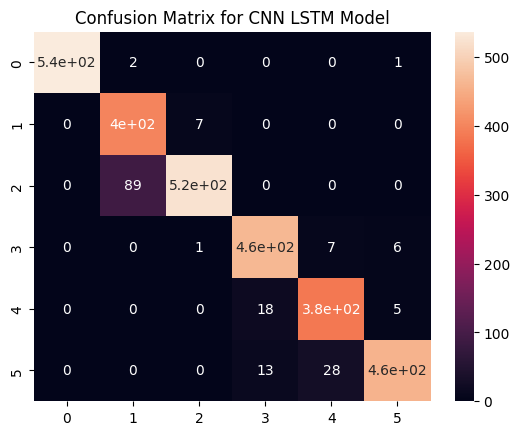

In [47]:
cnn_lstm_predict = CNN_LSTM_model.predict( test_features )
original = test_labels

cnn_lstm_predict = np.argmax(cnn_lstm_predict, axis=1)
cf = metrics.confusion_matrix(cnn_lstm_predict, original)

sns.heatmap(cf, annot=True)
plt.title('Confusion Matrix for CNN LSTM Model')
plt.show

In [46]:
cnn_model.evaluate(test_features, test_labels)

93/93 [==============================] - 0s 5ms/step - loss: 0.1747 - accuracy: 0.9603


[0.17473359405994415, 0.9602985978126526]

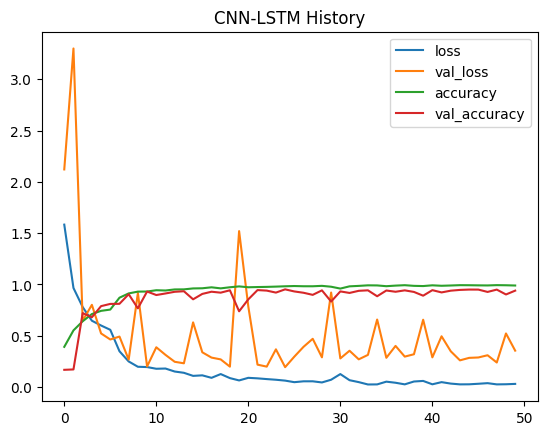

In [49]:
Graph_Drawing(cnn_lstm_history, "CNN-LSTM History")